In [2]:
library(randomForest)
library(MASS)
library(ggplot2)

randomForest 4.6-14
Type rfNews() to see new features/changes/bug fixes.
Registered S3 methods overwritten by 'ggplot2':
  method         from 
  [.quosures     rlang
  c.quosures     rlang
  print.quosures rlang

Attaching package: 'ggplot2'

The following object is masked from 'package:randomForest':

    margin



In [3]:
data("Boston")
set.seed(42)

In [4]:
sample_index <- sample(1:nrow(Boston), 0.8 * nrow(Boston))
train_data <- Boston[sample_index, ]
test_data <- Boston[-sample_index, ]

In [5]:
rf_model <- randomForest(medv ~ ., data = train_data, ntree = 100)

In [6]:
predictions <- predict(rf_model, test_data)
actuals <- test_data$medv

In [7]:
errors <- actuals - predictions
mae_val <- mean(abs(errors))
rmse_val <- sqrt(mean(errors^2))
r2_val <- 1 - (sum(errors^2) / sum((actuals - mean(actuals))^2))

In [8]:
cat("Mean Absolute Error:", mae_val, "\n")
cat("Root Mean Squared Error:", rmse_val, "\n")
cat("R-squared:", r2_val, "\n")

Mean Absolute Error: 2.315949 
Root Mean Squared Error: 3.517072 
R-squared: 0.8795295 


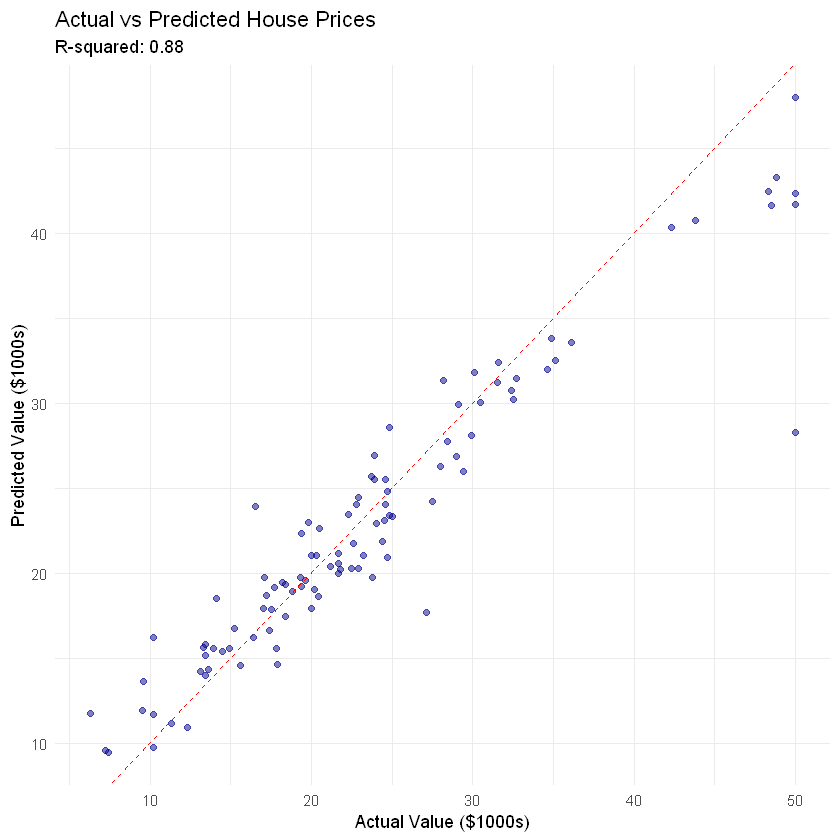

In [9]:
plot_data <- data.frame(Actual = actuals, Predicted = predictions)
ggplot(plot_data, aes(x = Actual, y = Predicted)) +
  geom_point(alpha = 0.5, color = "darkblue") +
  geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
  labs(title = "Actual vs Predicted House Prices",
       subtitle = paste("R-squared:", round(r2_val, 3)),
       x = "Actual Value ($1000s)", 
       y = "Predicted Value ($1000s)") +
  theme_minimal()